curl  -C - https://downloads.psl.noaa.gov//Datasets/godas/pottmp.1982.nc --output godas/sst/pottmp_1982.nc

In [ ]:
curl  -C  - 'https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr/202304/oisst-avhrr-v02r01.20230401.nc' --output oisst-avhrr-v02r01.20230401.nc

In [1]:
import datetime
import pandas as pd

In [12]:
t=pd.date_range('20221014','20230401')
w=open('oisst_add_20221014_20230401.bat','w')
for i in t:
    w.write(f"curl  -C  - 'https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr/{i.year}{i.month:02d}/oisst-avhrr-v02r01.{i.year}{i.month:02d}{i.day:02d}.nc' --output oisst-avhrr-v02r01.{i.year}{i.month:02d}{i.day:02d}.nc")
    w.write('\n')
w.close()

In [9]:
# BRAN2020

In [ ]:
#https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_mld_1993_01.nc

In [ ]:
set http_proxy=http://127.0.0.1:10809 & set https_proxy=http://127.0.0.1:10809

In [13]:
t=pd.date_range('19930101','20221231',freq='M')
w=open('Bran2020_mld.bat','w')
#w.write('set http_proxy=http://127.0.0.1:10809\nset https_proxy=http://127.0.0.1:10809\ncurl google.com\n')
for i in t:
    #w.write(f"wget  -c https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.year}_{i.month:02d}.nc ")
    #w.write(f"https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.year}_{i.month:02d}.nc ")
    w.write('\n')
w.close()

In [7]:
t=pd.date_range('19930101','20221231',freq='M')
w=open('Bran2020_flux.bat','w')
for i in t:
    #w.write(f"wget  -c 'https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/atm_flux_diag_{i.year}_{i.month:02d}.nc' ")
    w.write(f"https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/atm_flux_diag_{i.year}_{i.month:02d}.nc")
    w.write('\n')
w.close()

In [2]:
t=pd.date_range('19930101','20221231',freq='M')
w=open('Bran2020_temp.bat','w')
for i in t:
    #w.write(f"wget  -c 'https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.year}_{i.month:02d}.nc' ")
    w.write(f"https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.year}_{i.month:02d}.nc")
    w.write('\n')
w.close()

In [3]:
t=pd.date_range('19930101','20221231',freq='M')
w=open('Bran2020_u.bat','w')
for i in t:
    #w.write(f"wget  -c 'https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_u_{i.year}_{i.month:02d}.nc' ")
    w.write(f"https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_u_{i.year}_{i.month:02d}.nc")
    w.write('\n')
w.close()

In [4]:
t=pd.date_range('19930101','20221231',freq='M')
w=open('Bran2020_v.bat','w')
for i in t:
    #w.write(f"wget  -c 'https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc' ")
    w.write(f"https://dapds00.nci.org.au/thredds/fileServer/gb6/BRAN/BRAN2020/daily/ocean_v_{i.year}_{i.month:02d}.nc")
    w.write('\n')
w.close()

In [2]:
import os
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt 
import xarray as xr
import pandas as pd
import datetime
def wr(txt):
    w=open('日志.log','a')
    w.write(txt)
    w.close()

http_proxy = "socks://127.0.0.1:10808"
https_proxy = "socks://127.0.0.1:10808"

os.environ['HTTP_PROXY'] = http_proxy
os.environ['HTTPS_PROXY'] = https_proxy

In [4]:
print(datetime.datetime.now())

2023-04-20 12:13:46.354234


In [47]:
t=pd.date_range('19930101','20221231',freq='M')
ts=pd.date_range('19930101','20221231',freq='D')
i=t[0]
ts[(ts.year==i.year)&(ts.month==i.month)].shape[0]

31

x 1499:1:2499
y 949:1:1399
z 0:1:33

In [2]:

t=pd.date_range('19930101','20221231',freq='M')
ts=pd.date_range('19930101','20221231',freq='D')

wr(f'{datetime.datetime.now()}: Start Download : \n')
for i in t:
    wr(f'{datetime.datetime.now()}:   MLD Download : ocean_mld_{i.year}_{i.month:02d}.nc \n')
    ml=ts[(ts.year==i.year)&(ts.month==i.month)].shape[0]-1
    das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_mld_{i.year}_{i.month:02d}.nc?xt_ocean[1499:1:2499],yt_ocean[949:1:1399],Time[0:1:{ml}],mld[0:1:{ml}][949:1:1399][1499:1:2499]')
    das.to_netcdf(rf'E:\OceanData\Bran\mld\ocean_mld_{i.year}_{i.month:02d}.nc')
    wr(f'{datetime.datetime.now()}:   MLD Down End : Save To E:\OceanData\Bran\mld\ocean_mld_{i.year}_{i.month:02d}.nc')
    wr('\n')
    
    wr(f'{datetime.datetime.now()}:  TEMP Download : ocean_mld_{i.year}_{i.month:02d}.nc \n')
    ml=ts[(ts.year==i.year)&(ts.month==i.month)].shape[0]-1
    das=xr.open_dataset(f'https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_{i.year}_{i.month:02d}.nc?xt_ocean[1499:1:2499],yt_ocean[949:1:1399],st_ocean[0:1:33],Time[0:1:{ml}],temp[0:1:{ml}][0:1:33][949:1:1399][1499:1:2499]')
    das.to_netcdf(rf'E:\OceanData\Bran\temp\ocean_temp_{i.year}_{i.month:02d}.nc')
    wr(f'{datetime.datetime.now()}:  TEMP Down End : Save To E:\OceanData\Bran\mld\ocean_mld_{i.year}_{i.month:02d}.nc')
    wr('\n')
    
    

In [29]:


# 使用 session 对象下载数据
url = "https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_1993_01.nc?xt_ocean[1499:1:2499],yt_ocean[949:1:1399],st_ocean[0:1:33],Time[0:1:30],temp[0:1:0][0:1:33][949:1:1399][1499:1:2499]"
ds = xr.open_dataset(url)
ds.to_netcdf('test2.nc')

In [27]:
ds = xr.open_dataset(url)

In [ ]:
xr.backends.d

In [8]:
das=xr.open_dataset('https://dapds00.nci.org.au/thredds/dodsC/gb6/BRAN/BRAN2020/daily/ocean_temp_1993_01.nc?xt_ocean[1499:1:2499],yt_ocean[949:1:1399],st_ocean[0:1:33],Time[0:1:30],temp[0:1:0][0:1:0][949:1:1399][1499:1:2499]')

In [9]:
temp=np.array(das['temp'])

In [10]:
das.to_netcdf('test.nc')

In [11]:
#das=nc.Dataset(r'E:\OceanData\Bran\flux\atm_flux_diag_1993_01.nc')
das=nc.Dataset(r'test.nc')

In [12]:
das.variables.keys()

dict_keys(['xt_ocean', 'yt_ocean', 'st_ocean', 'Time', 'temp'])

In [13]:
np.array(das['Time']).shape

(31,)

In [14]:
st=np.array(das['st_ocean'])

In [15]:
st[st<=500].shape

(33,)

In [17]:
lon=np.array(das['xt_ocean'])
lat=np.array(das['yt_ocean'])

In [18]:
temp=np.array(das['temp'])
temp[temp<-90]=np.nan

In [13]:
lonind=(lon>=150)&(lon<=250)
latind=(lat>=20)&(lat<=65)

In [22]:
lon[lonind].shape

(1001,)

In [24]:
np.where(lat==lat[latind][0])

(array([949], dtype=int64),)

In [19]:
lon[lonind][0]

150.0

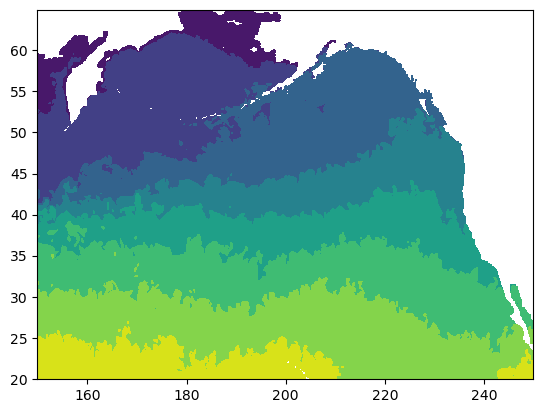

In [19]:
lonind=(lon>=150)&(lon<=250)
latind=(lat>=20)&(lat<=65)
Lon,Lat=np.meshgrid(lon,lat)

plt.contourf(Lon,Lat,temp[0,0,:,:])

In [6]:
dir(das)

['DODS_EXTRA.Unlimited_Dimension',
 'NCO',
 'NumFilesInSet',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__orthogonal_indexing__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '_close',
 '_close_mem',
 '_enddef',
 '_getname',
 '_grpid',
 '_isopen',
 '_ncstring_attrs__',
 '_redef',
 'acknowledgement',
 'catalogue_doi_url',
 'close',
 'cmptypes',
 'createCompoundType',
 'createDimension',
 'createEnumType',
 'createGroup',
 'createVLType',
 'createVariable',
 'data_model',
 'delncattr',
 'dimensions',
 'disk_format',
 'enumtypes',
 'file_format',
 'filename',
 'filepath',
 'fromcdl',
 'get_variables_by_attributes',
 'getncattr',
 'grid_tile',
 'grid_type',
 'groups',
 'has_blosc_filter',
 'has_